# Ejercicio 2. Clasificación de prendas de vestir con una red de dos capas ocultas (Fashion MNIST)

Curso de Inteligencia Artificial y Minirobots. Capítulo 5, Introducción a las Redes Neuronales Artificiales (José J. Martínez P.)

Ejercicio 5.9, numeral 2: *Con base en la librería tensorflow, descargue el data set fashion MNIST. Haga una clasificación de prendas de vestir. Use una red neuronal con dos capas ocultas y pruebe el modelo, ¿qué precisión obtuvo? Saque conclusiones.*

---

## 1. Planteamiento

Fashion MNIST fue publicado por Zalando Research como reemplazo directo del MNIST de dígitos descrito en la sección 5.4 del capítulo. Conserva el mismo formato: imágenes en escala de grises de 28 × 28 = 784 píxeles, 60 000 ejemplos de entrenamiento, 10 000 de prueba y 10 clases. En lugar de dígitos, cada imagen es una prenda o un accesorio.

En la notación del capítulo, cada par $(X^{(i)}, Y^{(i)})$ tiene un vector de características $X^{(i)}$ de 784 valores y un rótulo $Y^{(i)}\in\{0,\dots,9\}$: es un problema de **multi-clasificación** con $k = 10$ clases.

El enunciado pide una red con **dos capas ocultas**. El notebook:

1. construye y entrena esa red, y comprueba que tiene exactamente dos capas ocultas;
2. la prueba con las 10 000 imágenes de prueba y reporta su **exactitud** y su **precisión**;
3. verifica a mano la propagación a través de las dos capas ocultas;
4. compara la red con otras de cero y una capa oculta, con varias semillas, para saber qué aporta la segunda capa;
5. analiza los errores y lo que representan las capas ocultas.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.decomposition import PCA

print("Version de TensorFlow:", tf.__version__)
tf.keras.utils.set_random_seed(2026)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

I0000 00:00:1790554982.599098   18975 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1790554984.228369   18975 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Version de TensorFlow: 2.21.0


## 2. Descarga y exploración de los datos

Entrenamiento: (60000, 28, 28) uint8   rotulos: (60000,)
Prueba:        (10000, 28, 28) uint8   rotulos: (10000,)
Rango de los pixeles: 0 a 255
Ejemplos por clase en entrenamiento: [6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]
Ejemplos por clase en prueba:        [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


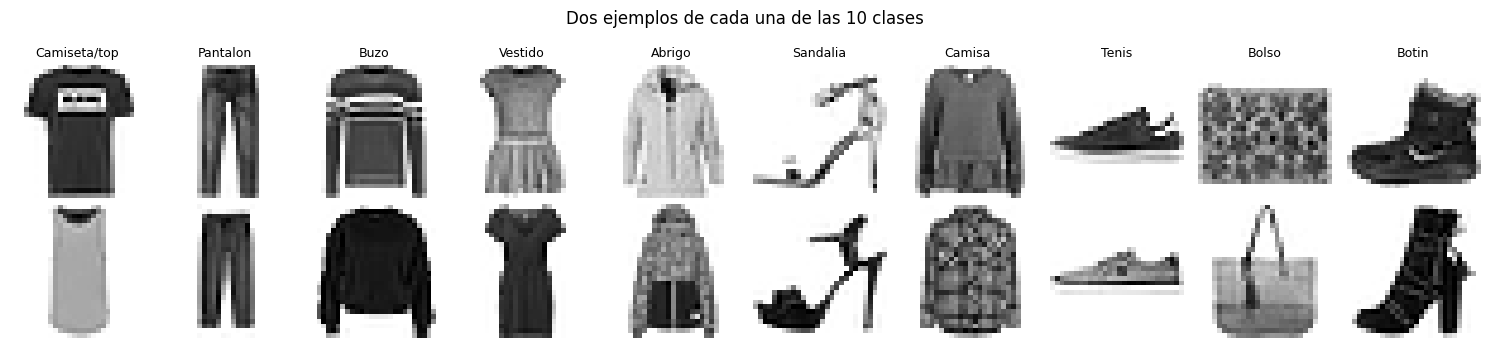

In [2]:
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
nombres = ["Camiseta/top", "Pantalon", "Buzo", "Vestido", "Abrigo",
           "Sandalia", "Camisa", "Tenis", "Bolso", "Botin"]

print("Entrenamiento:", x_train_full.shape, x_train_full.dtype, "  rotulos:", y_train_full.shape)
print("Prueba:       ", x_test.shape, x_test.dtype, "  rotulos:", y_test.shape)
print("Rango de los pixeles:", x_train_full.min(), "a", x_train_full.max())
print("Ejemplos por clase en entrenamiento:", np.bincount(y_train_full))
print("Ejemplos por clase en prueba:       ", np.bincount(y_test))

fig, ax = plt.subplots(2, 10, figsize=(15, 3.6))
for c in range(10):
    idx = np.where(y_train_full == c)[0][:2]
    for f in range(2):
        ax[f, c].imshow(x_train_full[idx[f]], cmap="gray_r"); ax[f, c].axis("off")
    ax[0, c].set_title(nombres[c], fontsize=9)
plt.suptitle("Dos ejemplos de cada una de las 10 clases"); plt.tight_layout(); plt.show()

`tf.keras.datasets.fashion_mnist.load_data()` descarga el conjunto la primera vez (unos 30 MB) y lo devuelve como arreglos de NumPy: imágenes `uint8` de 28 × 28 con valores de 0 a 255, y rótulos enteros de 0 a 9. Las diez clases están perfectamente balanceadas (6 000 imágenes de cada una en entrenamiento y 1 000 en prueba), así que un clasificador al azar acertaría el 10 %.

## 3. Preprocesamiento y división del conjunto

In [3]:
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train, y_train = x_train_full[:50_000], y_train_full[:50_000]
x_val, y_val = x_train_full[50_000:], y_train_full[50_000:]
print("Entrenamiento:", len(x_train), "  Validacion:", len(x_val), "  Prueba:", len(x_test))

Entrenamiento: 50000   Validacion: 10000   Prueba: 10000


Los píxeles se dividen por 255 para llevarlos al intervalo $[0,1]$. Como indica la sección 5.4 del capítulo, se usan tres conjuntos: **entrenamiento** (50 000) para ajustar los pesos, **validación** (10 000, los últimos del conjunto original) para decidir cuándo detener el entrenamiento, y **prueba** (10 000) para medir el desempeño final. El conjunto de prueba no se usa para ninguna decisión: se evalúa una sola vez, al final.

## 4. La red con dos capas ocultas

### 4.1 Arquitectura

In [4]:
def red_dos_capas(n1=256, n2=128, p_dropout=0.2, nombre="dos_capas_ocultas"):
    return tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28)),                                   # capa 0: la imagen
        tf.keras.layers.Flatten(name="aplanar"),                          # 28x28 -> vector X de 784
        tf.keras.layers.Dense(n1, activation="relu", name="oculta_1"),    # primera capa oculta
        tf.keras.layers.Dropout(p_dropout, name="dropout_1"),
        tf.keras.layers.Dense(n2, activation="relu", name="oculta_2"),    # segunda capa oculta
        tf.keras.layers.Dropout(p_dropout, name="dropout_2"),
        tf.keras.layers.Dense(10, activation="softmax", name="salida"),   # capa de salida: 10 clases
    ], name=nombre)

tf.keras.utils.set_random_seed(2026)
modelo = red_dos_capas()
modelo.summary()

densas = [c for c in modelo.layers if isinstance(c, tf.keras.layers.Dense)]
print("Capas con pesos (Dense):", [c.name for c in densas])
print("Capas ocultas:", [c.name for c in densas[:-1]], "->", len(densas) - 1, "capas ocultas")

Model: "dos_capas_ocultas"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aplanar (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_1 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Capas con pesos (Dense): ['oculta_1', 'oculta_2', 'salida']
Capas ocultas: ['oculta_1', 'oculta_2'] -> 2 capas ocultas


**Instrucciones de esta celda.**

- `tf.keras.Sequential` apila las capas en orden: la salida de cada una es la entrada de la siguiente, como en la red *feedforward* de la figura 5.13 del capítulo.
- `Flatten` convierte la imagen de 28 × 28 en el vector $X$ de 784 características. No tiene pesos.
- `Dense(256, activation="relu", name="oculta_1")` es la **primera capa oculta**: 256 neuronas completamente conectadas a las 784 entradas, con activación ReLU, $g(z) = \max(0, z)$. Calcula $A^{(1)} = \text{ReLU}(W^{(1)T}X + B^{(1)})$.
- `Dense(128, activation="relu", name="oculta_2")` es la **segunda capa oculta**: 128 neuronas que reciben las 256 salidas de la primera. Calcula $A^{(2)} = \text{ReLU}(W^{(2)T}A^{(1)} + B^{(2)})$.
- `Dense(10, activation="softmax", name="salida")` es la **capa de salida**, con una neurona por clase. La función softmax convierte las diez salidas en probabilidades que suman 1: $\text{softmax}(z)_j = e^{z_j}/\sum_i e^{z_i}$.
- `Dropout(0.2)`, después de cada capa oculta, apaga al azar el 20 % de sus neuronas en cada paso del entrenamiento, para que la red no dependa de combinaciones muy específicas y se reduzca el sobreentrenamiento. No tiene pesos y no actúa al predecir, así que **no es una capa oculta**: no agrega neuronas ni transforma los datos en la inferencia.

La lista de capas con pesos lo confirma: la red tiene **exactamente dos capas ocultas**, `oculta_1` y `oculta_2`, más la capa de salida. El número de neuronas va disminuyendo (784 → 256 → 128 → 10), una disposición habitual en la que cada capa resume la anterior en menos valores.

**Parámetros.** Primera capa oculta: $784\cdot256 + 256 = 200\,960$. Segunda: $256\cdot128 + 128 = 32\,896$. Salida: $128\cdot10 + 10 = 1\,290$. Total: $235\,146$, lo mismo que reporta `summary()`.

**Configuración del aprendizaje.** Se usa el optimizador Adam con tasa de aprendizaje $\eta = 0.001$, una variante del descenso del gradiente de la sección 5.5 que adapta el paso de cada peso, y la entropía cruzada como función de pérdida, $E = -\ln p_y$, que es la adecuada para una salida softmax. Los pesos se actualizan cada 32 imágenes. `EarlyStopping` detiene el entrenamiento cuando la pérdida de validación no mejora durante 5 épocas y restaura los pesos de la mejor época.

### 4.2 Entrenamiento

In [5]:
def compila(m):
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

def entrena(m, epocas=50, verbose=0):
    parada = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    t0 = time.time()
    h = m.fit(x_train, y_train, epochs=epocas, batch_size=32, validation_data=(x_val, y_val),
              callbacks=[parada], verbose=verbose)
    return h, time.time() - t0

compila(modelo)
hist, t_modelo = entrena(modelo, verbose=2)
mejor = int(np.argmin(hist.history["val_loss"])) + 1
print(f"\nEntrenamiento detenido tras {len(hist.history['loss'])} epocas ({t_modelo:.0f} s); "
      f"pesos restaurados de la epoca {mejor}")

Epoch 1/50


1563/1563 - 8s - 5ms/step - accuracy: 0.8012 - loss: 0.5529 - val_accuracy: 0.8333 - val_loss: 0.4391


Epoch 2/50


1563/1563 - 7s - 4ms/step - accuracy: 0.8505 - loss: 0.4095 - val_accuracy: 0.8489 - val_loss: 0.3978


Epoch 3/50


...

Epoch 26/50


1563/1563 - 7s - 4ms/step - accuracy: 0.9154 - loss: 0.2231 - val_accuracy: 0.8952 - val_loss: 0.3287


Epoch 27/50


1563/1563 - 7s - 4ms/step - accuracy: 0.9190 - loss: 0.2178 - val_accuracy: 0.8993 - val_loss: 0.3223



Entrenamiento detenido tras 27 epocas (199 s); pesos restaurados de la epoca 22


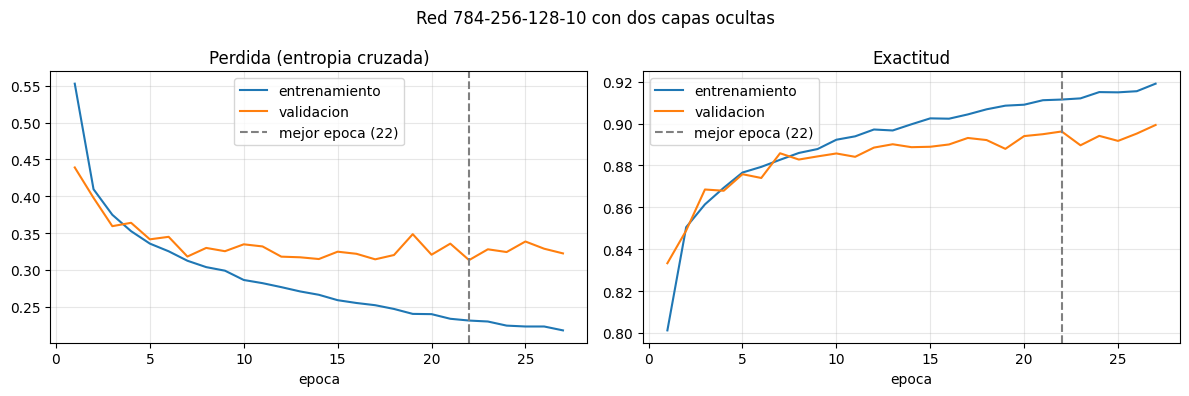

In [6]:
ep = np.arange(1, len(hist.history["loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ep, hist.history["loss"], label="entrenamiento"); ax[0].plot(ep, hist.history["val_loss"], label="validacion")
ax[1].plot(ep, hist.history["accuracy"], label="entrenamiento"); ax[1].plot(ep, hist.history["val_accuracy"], label="validacion")
for a, t in zip(ax, ("Perdida (entropia cruzada)", "Exactitud")):
    a.axvline(mejor, color="gray", ls="--", label=f"mejor epoca ({mejor})"); a.set_xlabel("epoca"); a.set_title(t); a.legend()
plt.suptitle("Red 784-256-128-10 con dos capas ocultas"); plt.tight_layout(); plt.show()

La pérdida de entrenamiento baja durante todas las épocas, mientras que la de validación deja de mejorar hacia la época 20: la mejor fue la 22, con una exactitud de validación de 89.6 %, y como en las 5 épocas siguientes no hubo mejora el entrenamiento se detuvo en la época 27. La distancia entre las dos curvas crece poco a poco (91.1 % frente a 89.6 % de exactitud en la época 22): el *Dropout* retrasa el sobreentrenamiento pero no lo elimina, y la parada temprana escoge el punto antes de que empeore la validación, como describe la figura 5.17 del capítulo.

## 5. Prueba del modelo: ¿qué precisión se obtuvo?

In [7]:
perdida_prueba, exactitud_prueba = modelo.evaluate(x_test, y_test, verbose=0)
P = modelo.predict(x_test, verbose=0)
pred = P.argmax(axis=1)

prec_macro = precision_score(y_test, pred, average="macro")
sens_macro = recall_score(y_test, pred, average="macro")
f1_macro = f1_score(y_test, pred, average="macro")
aciertos = int((pred == y_test).sum())

print("Resultado en el conjunto de prueba (10 000 imagenes que la red nunca vio):")
print(f"   Aciertos:                     {aciertos} de {len(y_test)}")
print(f"   Exactitud (accuracy):         {exactitud_prueba:.4f}")
print(f"   Precision promedio (macro):   {prec_macro:.4f}")
print(f"   Sensibilidad promedio:        {sens_macro:.4f}")
print(f"   F1 promedio:                  {f1_macro:.4f}")
print(f"   Perdida (entropia cruzada):   {perdida_prueba:.4f}")

# intervalo de confianza del 95 % para la exactitud (aproximacion normal)
ee = np.sqrt(exactitud_prueba * (1 - exactitud_prueba) / len(y_test))
print(f"\nIntervalo de confianza del 95 % para la exactitud: {exactitud_prueba - 1.96*ee:.4f} a {exactitud_prueba + 1.96*ee:.4f}")

print("\nPrecision, sensibilidad y F1 por clase:")
print(classification_report(y_test, pred, target_names=nombres, digits=3))

Resultado en el conjunto de prueba (10 000 imagenes que la red nunca vio):
   Aciertos:                     8872 de 10000
   Exactitud (accuracy):         0.8872
   Precision promedio (macro):   0.8870
   Sensibilidad promedio:        0.8872
   F1 promedio:                  0.8867
   Perdida (entropia cruzada):   0.3428

Intervalo de confianza del 95 % para la exactitud: 0.8810 a 0.8934

Precision, sensibilidad y F1 por clase:
              precision    recall  f1-score   support

Camiseta/top      0.804     0.868     0.835      1000
    Pantalon      0.991     0.974     0.982      1000
        Buzo      0.787     0.815     0.801      1000
     Vestido      0.872     0.896     0.884      1000
      Abrigo      0.811     0.798     0.804      1000
    Sandalia      0.985     0.957     0.971      1000
      Camisa      0.734     0.661     0.696      1000
       Tenis      0.949     0.964     0.956      1000
       Bolso      0.983     0.971     0.977      1000
       Botin      0.954     

**La red de dos capas ocultas clasificó correctamente 8 872 de las 10 000 prendas de prueba: una exactitud de 88.7 %**, con un intervalo de confianza del 95 % de 88.1 % a 89.3 %. Como referencia, un clasificador al azar acertaría el 10 %.

Sobre el término *precisión*: en el lenguaje común se usa para la proporción de aciertos, que en clasificación se llama **exactitud** (*accuracy*). En aprendizaje de máquina, la **precisión** (*precision*) es otra medida: de las imágenes que la red asignó a una clase, qué fracción era realmente de esa clase. Se reportan las dos. Como las clases están balanceadas, sus promedios coinciden: precisión promedio de 88.7 %, sensibilidad de 88.7 % y F1 de 88.7 %.

El desempeño por clase es muy desigual. Pantalón, bolso, sandalia, botín y tenis superan el 95 % en precisión y sensibilidad, porque su silueta es inconfundible. En el otro extremo está **Camisa**, con 73 % de precisión y solo 66 % de sensibilidad: la red detecta dos de cada tres camisas, y cuando dice "camisa" se equivoca una de cada cuatro veces. Buzo y abrigo están alrededor del 80 %.

## 6. Verificación: la propagación por las dos capas ocultas, a mano

Se extraen los pesos con `get_weights()` y se repite con NumPy la propagación de la sección 5.4 del capítulo, capa por capa. En la inferencia `Dropout` no actúa, así que no aparece en las ecuaciones:

$$Z^{(1)} = W^{(1)T}X + B^{(1)},\quad A^{(1)} = \text{ReLU}(Z^{(1)})\qquad\text{(primera capa oculta)}$$
$$Z^{(2)} = W^{(2)T}A^{(1)} + B^{(2)},\quad A^{(2)} = \text{ReLU}(Z^{(2)})\qquad\text{(segunda capa oculta)}$$
$$Z^{(3)} = W^{(3)T}A^{(2)} + B^{(3)},\quad A^{(3)} = \text{softmax}(Z^{(3)})\qquad\text{(salida)}$$

In [8]:
W1, B1, W2, B2, W3, B3 = modelo.get_weights()
for k, (Wk, Bk) in enumerate(((W1, B1), (W2, B2), (W3, B3)), start=1):
    print(f"W{k} {str(Wk.shape):<11} B{k} {str(Bk.shape):<7} -> {Wk.size + Bk.size:>7,} parametros")

X = x_test.reshape(-1, 784)
A1 = np.maximum(0, X @ W1 + B1)                  # primera capa oculta
A2 = np.maximum(0, A1 @ W2 + B2)                 # segunda capa oculta
Z3 = A2 @ W3 + B3
A3 = np.exp(Z3 - Z3.max(axis=1, keepdims=True)); A3 /= A3.sum(axis=1, keepdims=True)   # softmax

print("\nDiferencia maxima entre las probabilidades de NumPy y de Keras:", np.abs(A3 - P).max())
print("Predicciones de clase identicas:", int((A3.argmax(1) == pred).sum()), "de", len(pred))

W1 (784, 256)  B1 (256,)  -> 200,960 parametros
W2 (256, 128)  B2 (128,)  ->  32,896 parametros
W3 (128, 10)   B3 (10,)   ->   1,290 parametros

Diferencia maxima entre las probabilidades de NumPy y de Keras: 1.3411045e-06
Predicciones de clase identicas: 10000 de 10000


Las probabilidades calculadas a mano con las tres matrices de pesos coinciden con las de Keras con una diferencia máxima de $10^{-6}$, que es el redondeo de la precisión simple, y las 10 000 predicciones son idénticas. Esto confirma dos cosas: que la red tiene exactamente las dos capas ocultas descritas, y que Keras calcula las mismas ecuaciones de propagación del capítulo.

## 7. ¿Qué aporta la segunda capa oculta?

Para saber qué aporta cada capa oculta, se entrenan en las mismas condiciones (mismos datos, optimizador, tamaño de lote y parada temprana) tres redes:

- **sin capas ocultas** (784‑10): las entradas conectadas directamente a la salida. Solo puede trazar fronteras lineales entre las clases;
- **con una capa oculta** de 300 neuronas (784‑300‑10). Se escogieron 300 neuronas para que tenga **casi el mismo número de parámetros** que la red de dos capas (238 510 frente a 235 146). Así la comparación mide el efecto de la profundidad, no el de tener más pesos;
- **con dos capas ocultas** (784‑256‑128‑10), la red del ejercicio.

Cada red se entrena con **tres semillas** distintas, porque con una sola corrida no se puede saber si una diferencia de pocas décimas se debe a la arquitectura o a la inicialización. La celda tarda entre 10 y 15 minutos en CPU.

In [9]:
def red_sin_ocultas(nombre="sin_capas_ocultas"):
    return tf.keras.Sequential([tf.keras.Input(shape=(28, 28)), tf.keras.layers.Flatten(),
                                tf.keras.layers.Dense(10, activation="softmax")], name=nombre)

def red_una_capa(n=300, p_dropout=0.2, nombre="una_capa_oculta"):
    return tf.keras.Sequential([tf.keras.Input(shape=(28, 28)), tf.keras.layers.Flatten(),
                                tf.keras.layers.Dense(n, activation="relu", name="oculta_1"),
                                tf.keras.layers.Dropout(p_dropout),
                                tf.keras.layers.Dense(10, activation="softmax")], name=nombre)

arquitecturas = {
    "0 capas ocultas (784-10)":            lambda: red_sin_ocultas(),
    "1 capa oculta (784-300-10)":          lambda: red_una_capa(),
    "2 capas ocultas (784-256-128-10)":    lambda: red_dos_capas(),
}
SEMILLAS = (2026, 7, 42)
filas = []
t0 = time.time()
for nombre, construir in arquitecturas.items():
    for s in SEMILLAS:
        if nombre.startswith("2 capas") and s == 2026:
            m, h = modelo, hist                           # ya entrenado arriba con esta semilla
        else:
            tf.keras.utils.set_random_seed(s)
            m = compila(construir()); h, _ = entrena(m)
        l, a = m.evaluate(x_test, y_test, verbose=0)
        filas.append((nombre, s, m.count_params(), len(h.history["loss"]), a, l))
print(f"Tiempo total: {time.time() - t0:.0f} s\n")
comp = pd.DataFrame(filas, columns=["arquitectura", "semilla", "parametros", "epocas", "exactitud", "perdida"])
print(comp.to_string(index=False, formatters={"exactitud": "{:.4f}".format, "perdida": "{:.4f}".format,
                                              "parametros": "{:,}".format}))
resumen = comp.groupby("arquitectura", sort=False).agg(parametros=("parametros", "first"),
                                                       exactitud_media=("exactitud", "mean"),
                                                       desviacion=("exactitud", "std"),
                                                       perdida_media=("perdida", "mean"))
print("\nPromedio de las tres semillas:")
print(resumen.to_string(formatters={"exactitud_media": "{:.4f}".format, "desviacion": "{:.4f}".format,
                                    "perdida_media": "{:.4f}".format, "parametros": "{:,}".format}))

Tiempo total: 805 s

                    arquitectura  semilla parametros  epocas exactitud perdida
        0 capas ocultas (784-10)     2026      7,850      21    0.8417  0.4548
        0 capas ocultas (784-10)        7      7,850      18    0.8427  0.4493
        0 capas ocultas (784-10)       42      7,850      20    0.8440  0.4461
      1 capa oculta (784-300-10)     2026    238,510      16    0.8820  0.3440
      1 capa oculta (784-300-10)        7    238,510      15    0.8787  0.3437
      1 capa oculta (784-300-10)       42    238,510      19    0.8805  0.3501
2 capas ocultas (784-256-128-10)     2026    235,146      27    0.8872  0.3428
2 capas ocultas (784-256-128-10)        7    235,146      15    0.8768  0.3416
2 capas ocultas (784-256-128-10)       42    235,146      16    0.8790  0.3442

Promedio de las tres semillas:
                                 parametros exactitud_media desviacion perdida_media
arquitectura                                                            

Los resultados muestran dos efectos muy distintos:

- **La primera capa oculta aporta casi 4 puntos.** La exactitud pasa de 84.3 % sin capas ocultas a 88.0 % con una capa oculta, y la pérdida de prueba baja de 0.45 a 0.35. Es la diferencia entre un modelo lineal y uno no lineal, la misma que separa la neurona sola de la red con capas ocultas en la XOR.
- **La segunda capa oculta, con el mismo número de parámetros, prácticamente no cambia el resultado.** El promedio es 88.1 % con dos capas y 88.0 % con una, una diferencia de 0.06 puntos, mucho menor que la variación entre semillas de la red de dos capas (desviación de 0.55 puntos: de 87.7 % a 88.7 %). La pérdida de prueba es levemente menor con dos capas (0.343 frente a 0.346), también dentro de la variación.

La red principal del ejercicio, entrenada con la semilla 2026, obtuvo el mejor resultado de las nueve corridas (88.7 %), pero con las otras dos semillas su exactitud fue de 87.7 % y 87.9 %. El valor que mejor representa a la arquitectura es el promedio, **88.1 %**.

La conclusión es que, para este problema y con redes densas, lo que importa es tener capas ocultas; pasar de una a dos, con los mismos parámetros, no mejora de forma medible la exactitud. La información que falta para distinguir las prendas difíciles no se obtiene reorganizando los mismos píxeles en más capas densas.

## 8. Análisis de los errores

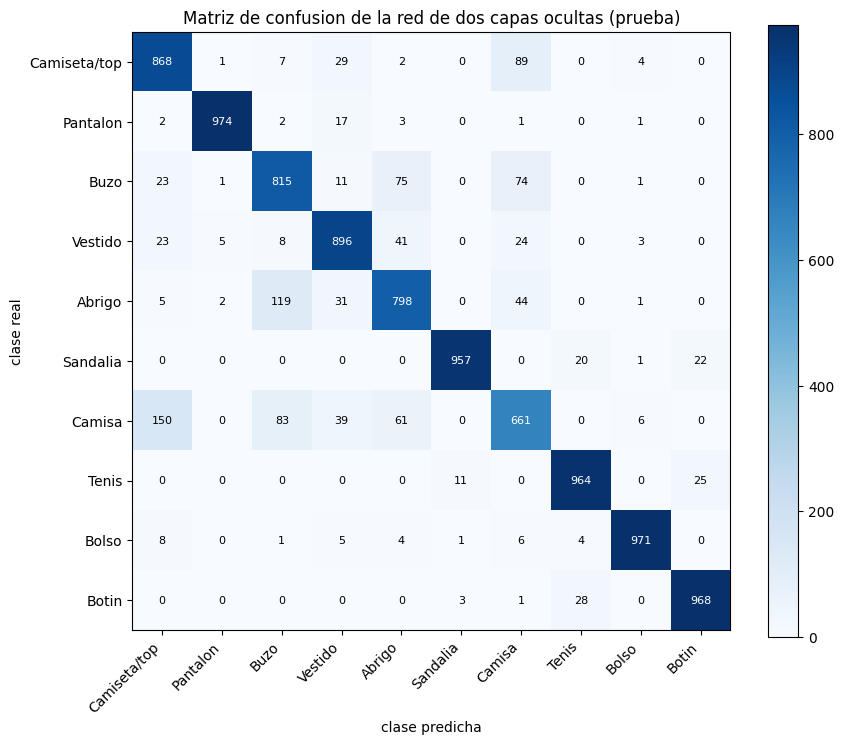

Confusiones mas frecuentes (real -> predicha):
    150  Camisa -> Camiseta/top
    119  Abrigo -> Buzo
     89  Camiseta/top -> Camisa
     83  Camisa -> Buzo
     75  Buzo -> Abrigo
     74  Buzo -> Camisa

Errores entre prendas superiores (camiseta, buzo, abrigo, camisa): 732 de 1128 errores


In [10]:
cm = tf.math.confusion_matrix(y_test, pred, num_classes=10).numpy()
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(cm, cmap="Blues")
for (r, c), v in np.ndenumerate(cm):
    ax.text(c, r, v, ha="center", va="center", fontsize=8, color="white" if v > 500 else "black")
ax.set_xticks(range(10)); ax.set_xticklabels(nombres, rotation=45, ha="right")
ax.set_yticks(range(10)); ax.set_yticklabels(nombres)
ax.set_xlabel("clase predicha"); ax.set_ylabel("clase real"); ax.grid(False)
ax.set_title("Matriz de confusion de la red de dos capas ocultas (prueba)")
fig.colorbar(im); plt.tight_layout(); plt.show()

errores = sorted(((cm[r, c], nombres[r], nombres[c]) for r in range(10) for c in range(10) if r != c), reverse=True)
print("Confusiones mas frecuentes (real -> predicha):")
for n, r, c in errores[:6]:
    print(f"   {n:>4}  {r} -> {c}")
sup = [0, 2, 4, 6]
print(f"\nErrores entre prendas superiores (camiseta, buzo, abrigo, camisa): "
      f"{cm[np.ix_(sup, sup)].sum() - np.trace(cm[np.ix_(sup, sup)])} de {len(y_test) - aciertos} errores")

Confianza media en los aciertos: 0.940   en los errores: 0.686
Imagenes con confianza >= 0.5:  96.8%   exactitud en ellas: 0.9022
Imagenes con confianza >= 0.9:  74.2%   exactitud en ellas: 0.9741
Imagenes con confianza >= 0.99:  57.7%   exactitud en ellas: 0.9903


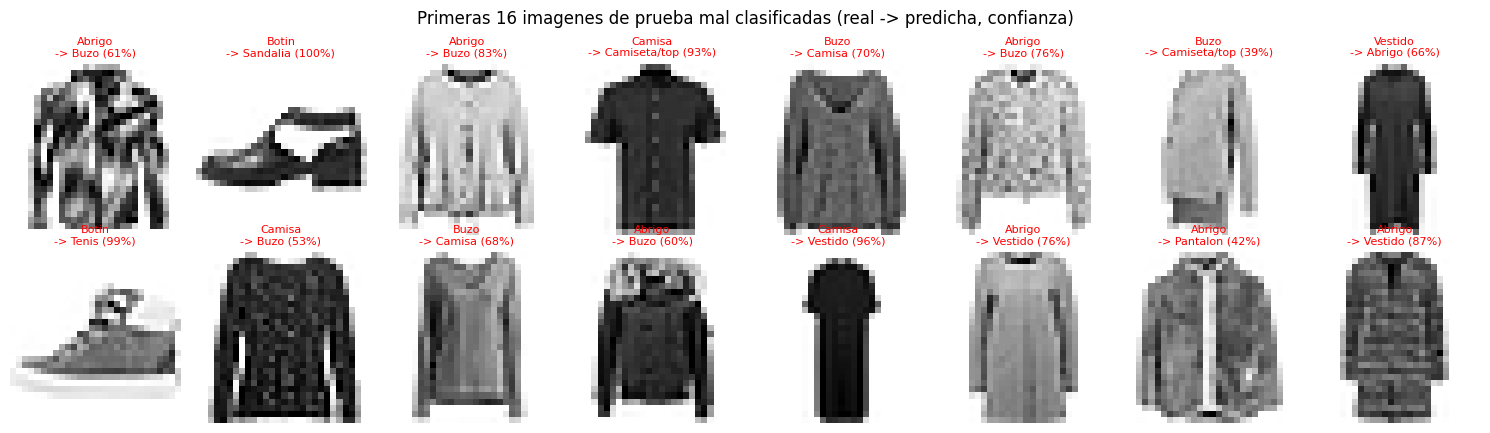

In [11]:
conf = P.max(axis=1)
bien = pred == y_test
print(f"Confianza media en los aciertos: {conf[bien].mean():.3f}   en los errores: {conf[~bien].mean():.3f}")
for u in (0.5, 0.9, 0.99):
    sel = conf >= u
    print(f"Imagenes con confianza >= {u}: {sel.mean():6.1%}   exactitud en ellas: {bien[sel].mean():.4f}")

mal = np.where(~bien)[0]
fig, ax = plt.subplots(2, 8, figsize=(15, 4.4))
for a, i in zip(ax.ravel(), mal[:16]):
    a.imshow(x_test[i], cmap="gray_r"); a.axis("off")
    a.set_title(f"{nombres[y_test[i]]}\n-> {nombres[pred[i]]} ({conf[i]:.0%})", fontsize=8, color="red")
plt.suptitle("Primeras 16 imagenes de prueba mal clasificadas (real -> predicha, confianza)")
plt.tight_layout(); plt.show()

Los errores no están repartidos al azar. De los 1 128 errores, **732 (65 %) ocurren entre las cuatro prendas superiores**: camiseta, buzo, abrigo y camisa. La confusión más frecuente es camisa → camiseta (150 casos), seguida de abrigo → buzo (119). A 28 × 28 píxeles estas prendas tienen casi la misma silueta y se diferencian por detalles como el cuello, los botones o el largo de la manga. En las imágenes mal clasificadas se ve además que algunas son ambiguas incluso para una persona.

La probabilidad que entrega softmax es informativa: la confianza media es de 0.94 en los aciertos y de 0.69 en los errores. Cuando la red asigna más de 0.99 a una clase (58 % de las imágenes), acierta el 99.0 % de las veces. En una aplicación real se podría aceptar automáticamente la respuesta en esos casos y pedir una revisión humana en los dudosos.

## 9. Lo que hacen las dos capas ocultas

Cada capa oculta transforma la imagen en un nuevo vector: 256 valores en la primera capa oculta y 128 en la segunda. Para ver el efecto de esas transformaciones se proyectan las imágenes de prueba en dos dimensiones con análisis de componentes principales (PCA) en cada etapa, y se mide qué tan agrupadas quedan las clases con un clasificador muy simple: asignar cada imagen a la clase cuyo **centroide** (el promedio de los vectores de esa clase en entrenamiento) esté más cerca. Si las clases forman grupos compactos y separados, ese clasificador acierta mucho.

pixeles (784)          exactitud por centroide mas cercano: 0.6792
capa oculta 1 (256)    exactitud por centroide mas cercano: 0.8071
capa oculta 2 (128)    exactitud por centroide mas cercano: 0.8124


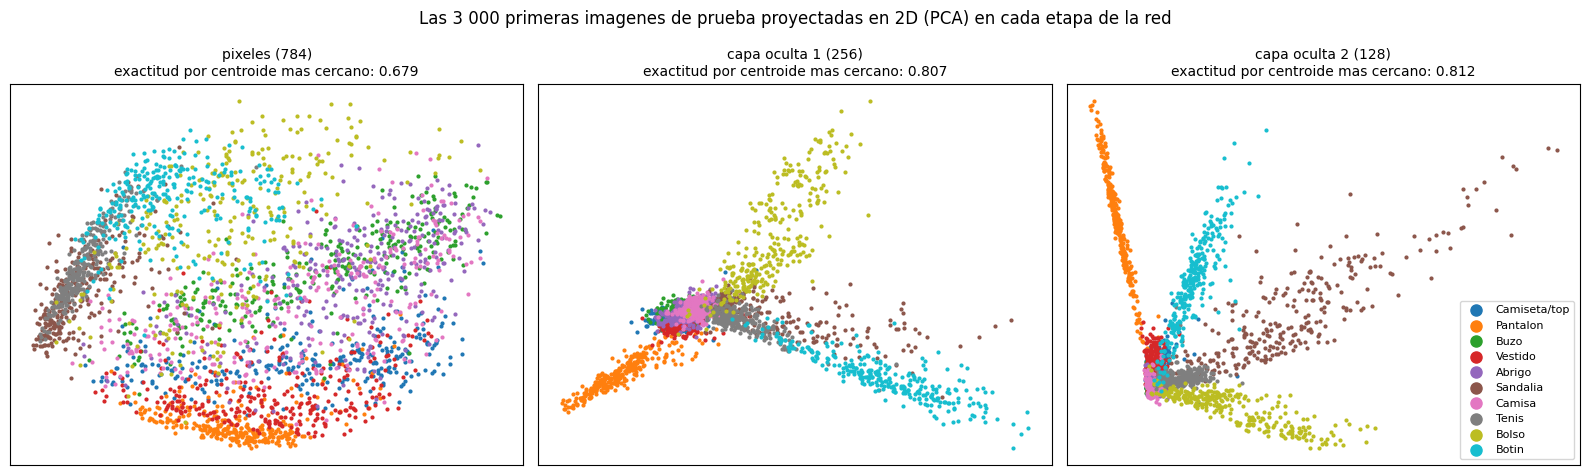

In [12]:
def exactitud_centroide(E_tr, y_tr, E_te, y_te):
    "Clasifica cada ejemplo por el centroide de clase mas cercano: mide que tan agrupadas estan las clases."
    C = np.stack([E_tr[y_tr == c].mean(axis=0) for c in range(10)])
    d = ((E_te[:, None, :] - C[None]) ** 2).sum(axis=2)
    return (d.argmin(axis=1) == y_te).mean()

Xtr = x_train.reshape(-1, 784)[:20_000]; ytr = y_train[:20_000]
rep_tr = {"pixeles (784)": Xtr,
          "capa oculta 1 (256)": np.maximum(0, Xtr @ W1 + B1)}
rep_tr["capa oculta 2 (128)"] = np.maximum(0, rep_tr["capa oculta 1 (256)"] @ W2 + B2)
rep_te = {"pixeles (784)": X, "capa oculta 1 (256)": A1, "capa oculta 2 (128)": A2}

fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))
colores = plt.cm.tab10(np.arange(10))
for a, (nombre, E) in zip(ax, rep_te.items()):
    acc_c = exactitud_centroide(rep_tr[nombre], ytr, E, y_test)
    Y2 = PCA(n_components=2, random_state=0).fit(rep_tr[nombre]).transform(E[:3000])
    for c in range(10):
        s = y_test[:3000] == c
        a.scatter(Y2[s, 0], Y2[s, 1], s=4, color=colores[c], label=nombres[c])
    a.set_title(f"{nombre}\nexactitud por centroide mas cercano: {acc_c:.3f}", fontsize=10)
    a.set_xticks([]); a.set_yticks([])
    print(f"{nombre:<22} exactitud por centroide mas cercano: {acc_c:.4f}")
ax[2].legend(markerscale=4, fontsize=8, loc="best")
plt.suptitle("Las 3 000 primeras imagenes de prueba proyectadas en 2D (PCA) en cada etapa de la red")
plt.tight_layout(); plt.show()

En el espacio de los píxeles, el clasificador por centroide acierta solo el 67.9 %: las clases se superponen. **Después de la primera capa oculta acierta el 80.7 %, y después de la segunda el 81.2 %.** En las proyecciones se ve el mismo efecto: las clases de calzado, los pantalones y los bolsos se separan en grupos definidos, mientras que las prendas superiores siguen superpuestas.

Esta es la función de las capas ocultas: transforman los datos de entrada en una representación en la que las clases quedan más separadas, de modo que la capa de salida pueda distinguirlas con fronteras simples. La mayor parte de esa reorganización la hace la primera capa oculta; la segunda la refina ligeramente, lo que concuerda con la comparación de la sección 7.

## 10. Predicción con imágenes individuales

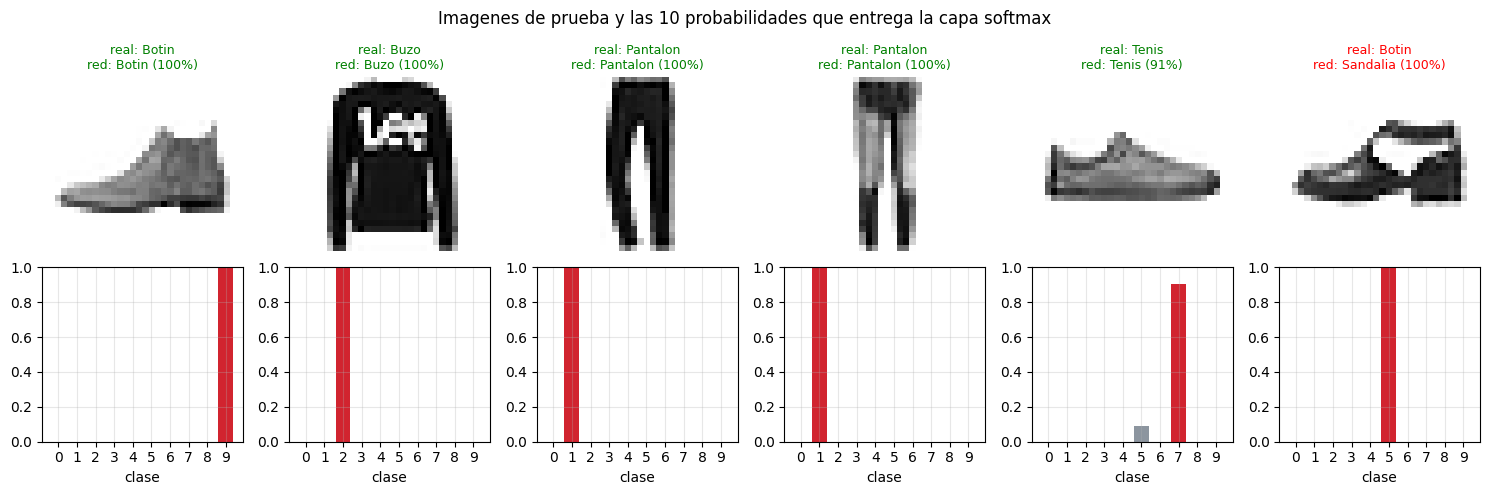

In [13]:
fig, ax = plt.subplots(2, 6, figsize=(15, 5))
for j, i in enumerate([0, 1, 2, 3, 12, 23]):
    color = "green" if pred[i] == y_test[i] else "red"
    ax[0, j].imshow(x_test[i], cmap="gray_r"); ax[0, j].axis("off")
    ax[0, j].set_title(f"real: {nombres[y_test[i]]}\nred: {nombres[pred[i]]} ({conf[i]:.0%})", fontsize=9, color=color)
    ax[1, j].bar(range(10), P[i], color=["#d1242f" if c == pred[i] else "#8c959f" for c in range(10)])
    ax[1, j].set_ylim(0, 1); ax[1, j].set_xticks(range(10)); ax[1, j].set_xlabel("clase")
plt.suptitle("Imagenes de prueba y las 10 probabilidades que entrega la capa softmax")
plt.tight_layout(); plt.show()

## 11. Conclusiones

1. **Precisión obtenida.** La red con dos capas ocultas (784‑256‑128‑10, ReLU, *Dropout* y parada temprana) clasificó correctamente **el 88.7 % de las 10 000 prendas de prueba** (8 872 aciertos), con una precisión promedio por clase también de 88.7 %. Repitiendo el entrenamiento con otras semillas la exactitud va de 87.7 % a 88.7 %, con un promedio de 88.1 %.
2. **Se verificó que la red tiene dos capas ocultas y que calcula las ecuaciones del capítulo.** La propagación repetida a mano con las tres matrices de pesos reproduce las 10 000 predicciones de TensorFlow.
3. **Las capas ocultas son imprescindibles, pero la segunda aporta poco en este problema.** Pasar de ninguna a una capa oculta sube la exactitud de 84.3 % a 88.0 %. Con los mismos parámetros, una segunda capa oculta deja la exactitud en 88.1 %, una diferencia que está dentro de la variación entre semillas. Más profundidad no es automáticamente mejor: depende de si el problema tiene una estructura que las capas adicionales puedan aprovechar.
4. **Las capas ocultas reorganizan los datos.** Un clasificador por centroide pasa de 67.9 % de aciertos sobre los píxeles a 81.2 % sobre la salida de la segunda capa oculta. La red aprende por sí misma una representación en la que las clases están más separadas.
5. **El error se concentra en prendas parecidas.** El 65 % de los errores ocurre entre camiseta, buzo, abrigo y camisa, y la camisa es la clase más difícil (66 % de sensibilidad). Una red densa trata cada píxel como una característica independiente y no aprovecha la estructura espacial de la imagen, que es donde están los detalles que distinguen estas prendas. El Ejercicio 5 aborda esa limitación con una red convolucional.
6. **La confianza de la red es útil.** Cuando la probabilidad de la clase predicha supera 0.99, la red acierta el 99 % de las veces; la mayor parte de los errores ocurre con probabilidades bajas.
7. **Buenas prácticas.** El conjunto de prueba se usó una sola vez; el número de épocas lo decidió el conjunto de validación, y las comparaciones entre arquitecturas se hicieron con varias semillas y con número de parámetros similar, para no confundir el efecto de la profundidad con el del tamaño de la red.